# `dippa.fitting` walkthrough

Same two jobs as the previous notebook: a fast manual check while
developing, and a first example for users once the API stabilises.

This one demonstrates the actual fitter — not just evaluating known
parameters (see `01_profiles_walkthrough.ipynb`), but finding them from a
genuinely bad starting guess. See `AUDIT.md` §11 for why the fitting
algorithm works the way it does (local decontaminated windows, not "freeze
other peaks and fit against the whole pattern").

## 1. Load the real reference pattern

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from pathlib import Path

from dippa.background import fit_background_quadratic
from dippa.fitting import fit_pattern
from dippa.profiles import evaluate_pattern

fixtures = Path("../tests/fixtures")
aa_real = scipy.io.loadmat(fixtures / "reference_fit.mat")["aa"]
data = scipy.io.loadmat(fixtures / "reference_data.mat")["data"]
x, y = data[:, 0], data[:, 1]
n_peaks = aa_real.shape[1] - 1
print(f"{n_peaks} peaks, {len(x)} measured points")

10 peaks, 13447 measured points


## 2. Build a deliberately bad starting guess

A real user supplies rough peak positions (e.g. by clicking on a plot) —
kept close to right here, just jittered within the fitting window. The
rest is deliberately wrong but, honestly stated, still *derived from* the
known answer: amplitudes are the true values scaled by a random factor in
[0.5, 1.5], and widths/etas are generic placeholders. So this is a
**recovery test from a perturbed start, not an independent start and not
MATLAB parity** — see `AUDIT.md` §15 for what that distinction costs
(per-side width/shape parameters are not individually identified by this
data; integral breadth is the quantity that recovers well).


In [2]:
rng = np.random.default_rng(42)
aa_guess = aa_real.copy()

for i in range(n_peaks):
    aa_guess[0, i] += rng.uniform(-0.005, 0.005)  # jitter position
    aa_guess[1, i] *= rng.uniform(0.5, 1.5)         # true amplitude scaled by +/-50%
    aa_guess[2, i] = 0.002                           # generic width guess
    aa_guess[3, i] = 0.5                             # generic eta guess
    aa_guess[4, i] = 0.002
    aa_guess[5, i] = 0.5

# Background re-derived from the (perturbed) guessed positions rather than
# copied from the reference fit's background column.
c0, c1, c2 = fit_background_quadratic(x, y, aa_guess[0, :n_peaks], half_width=0.02)
aa_guess[0, -1], aa_guess[1, -1], aa_guess[2, -1] = c0, c1, c2

def r_squared(y, model):
    ss_res = np.sum((y - model) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

model_guess = evaluate_pattern(x, aa_guess)
print(f"Starting R^2: {r_squared(y, model_guess):.3f}  (negative = worse than predicting the mean)")

Starting R^2: -1.225  (negative = worse than predicting the mean)


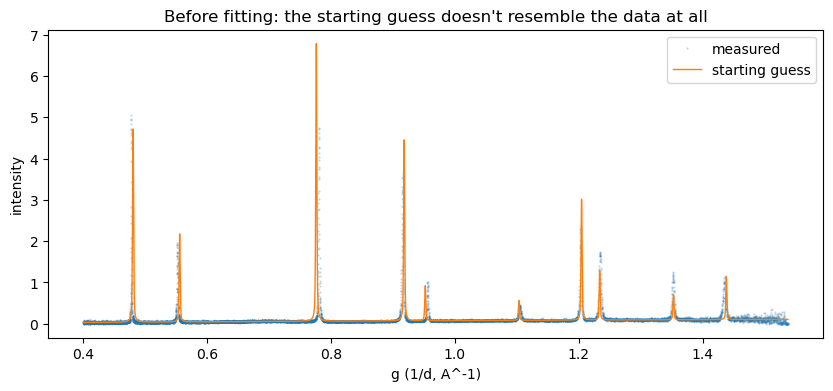

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, ".", markersize=1, alpha=0.3, label="measured")
ax.plot(x, model_guess, linewidth=1, label="starting guess")
ax.set_xlabel("g (1/d, A^-1)")
ax.set_ylabel("intensity")
ax.set_title("Before fitting: the starting guess doesn't resemble the data at all")
ax.legend()
plt.show()

## 3. Run the staged fitter

In [4]:
result = fit_pattern(x, y, aa_guess, half_width=0.02, n_passes=3)
aa_fitted = result.aa
model_fitted = evaluate_pattern(x, aa_fitted)
print(f"Final R^2: {r_squared(y, model_fitted):.4f}")
print(f"All fits clean (converged, no bound hits): {result.all_clean}")
for w in result.warnings:
    print("warning:", w)


Final R^2: 0.9937
All fits clean (converged, no bound hits): False


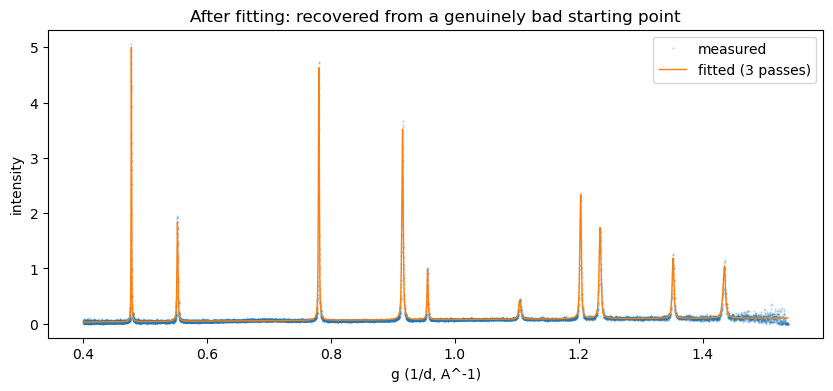

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, ".", markersize=1, alpha=0.3, label="measured")
ax.plot(x, model_fitted, linewidth=1, label="fitted (3 passes)")
ax.set_xlabel("g (1/d, A^-1)")
ax.set_ylabel("intensity")
ax.set_title("After fitting: recovered from a genuinely bad starting point")
ax.legend()
plt.show()

## 4. Convergence across passes

The fitter is staged: each pass refits every peak once, seeing the latest
estimate of every other peak from the previous pass (a Gauss-Seidel-style
scheme — see `AUDIT.md` §11 for why this is a deliberate simplification
versus the original tool's joint fitting of overlapping peaks). Worth
seeing how much of the improvement happens in the first pass versus later
ones.

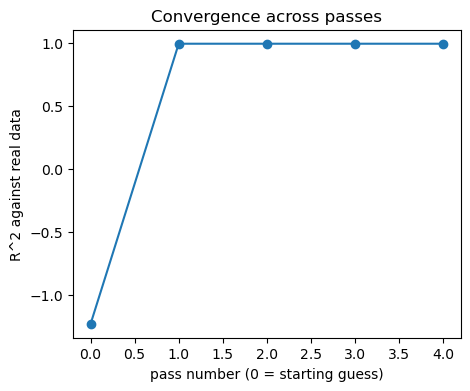

In [6]:
aa_progress = aa_guess.copy()
r2_by_pass = [r_squared(y, evaluate_pattern(x, aa_progress))]

for _ in range(4):
    aa_progress = fit_pattern(x, y, aa_progress, half_width=0.02, n_passes=1).aa
    r2_by_pass.append(r_squared(y, evaluate_pattern(x, aa_progress)))

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(range(len(r2_by_pass)), r2_by_pass, "o-")
ax.set_xlabel("pass number (0 = starting guess)")
ax.set_ylabel("R^2 against real data")
ax.set_title("Convergence across passes")
plt.show()

## 5. Read the diagnostics before trusting the widths

The fitter returns a structured result, not a bare array, because a fit
that "converged" with a parameter pinned at its bound is not a trustworthy
parameter estimate even when the pattern-level R² looks excellent. On this
very fixture, the weakest peak pins `eta_right` at the 1.3 upper bound —
its width/shape parameters trade off against each other with little
residual cost (`AUDIT.md` §15). Anything consuming breadths downstream
(modified Williamson-Hall) should check these warnings and prefer
integral breadth over raw per-side FWHM.


In [7]:
for r in result.peak_results:
    flag = "" if r.clean else "  <-- check"
    bounds = ", ".join(r.at_lower_bound + r.at_upper_bound) or "-"
    print(f"peak {r.peak_index}: success={r.success}  cost={r.cost:.4f}  "
          f"nfev={r.nfev}  at-bounds: {bounds}{flag}")

print("\naabcg (per-peak local background, original tool's convention):")
print(np.round(result.aabcg, 4))


peak 0: success=True  cost=0.9554  nfev=2  at-bounds: -
peak 1: success=True  cost=0.2244  nfev=2  at-bounds: -
peak 2: success=True  cost=0.1251  nfev=3  at-bounds: -
peak 3: success=True  cost=0.1473  nfev=2  at-bounds: -
peak 4: success=True  cost=0.0400  nfev=2  at-bounds: -
peak 5: success=True  cost=0.0319  nfev=3  at-bounds: -
peak 6: success=True  cost=0.0795  nfev=3  at-bounds: -
peak 7: success=True  cost=0.0917  nfev=3  at-bounds: -
peak 8: success=True  cost=0.0776  nfev=4  at-bounds: -
peak 9: success=True  cost=0.2120  nfev=2  at-bounds: eta_right  <-- check

aabcg (per-peak local background, original tool's convention):
[[-0.0043 -0.0538  0.2417  0.1419 -0.2052 -0.0749 -0.2035 -0.4143 -0.0724
  -0.4713]
 [-0.0013  0.0827 -0.3285 -0.1824  0.2033  0.0658  0.1544  0.329   0.0522
   0.3218]]
